# 02 - Analisis exploratorio (Ejercicio 4)

Las preguntas (4.1) y su justificacion estan en `docs/eda.md`; aqui se ejecutan las consultas (4.2) de `sql/02_eda/`, se grafican y se interpretan (4.4).
La vista `trips` unifica yellow y green; **no se eliminan registros**: cada consulta aplica y declara sus filtros de calidad.

In [1]:
import os, sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60, "display.width", 180, "display.max_colwidth", 60)

# Dentro del contenedor el proyecto esta en /workspace; fuera, en la carpeta padre de notebooks/.
RAIZ = Path("/workspace") if Path("/workspace/sql").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ / "scripts"))
import taxi_common as tc
DATOS = tc.data_dir().as_posix()          # carpeta data/ segun donde se ejecute
from document_queries import abrir

# FUENTE = "parquet": la vista `trips` lee los Parquet de data/raw (normalizados por taxi_common.py).
# FUENTE = "tabla"  : la vista `trips` apunta a la tabla de data/processed/taxi.duckdb (abierta en SOLO LECTURA).
# Las MISMAS consultas sirven para ambas fuentes. Para cambiar: LAB_FUENTE=tabla antes de iniciar Jupyter.
FUENTE = os.environ.get("LAB_FUENTE", "parquet")
con = abrir(FUENTE, str(tc.db_por_defecto()))

def sql(archivo: str) -> pd.DataFrame:
    """Ejecuta un archivo de sql/ y devuelve un DataFrame. La consulta vive en el .sql, no en el notebook."""
    texto = (RAIZ / "sql" / archivo).read_text(encoding="utf-8").replace("/workspace/data", DATOS)
    return con.execute(texto).df()

print("DuckDB", duckdb.__version__, "| fuente:", FUENTE, "| archivos:", len(tc.listar_archivos()))

DuckDB 1.5.5 | fuente: tabla | archivos: 64


## P1 - ¿Como evoluciona la demanda mes a mes?

Tendencia y estacionalidad (comportamiento temporal).

Consulta: `sql/02_eda/d10_tendencia_mensual.sql`

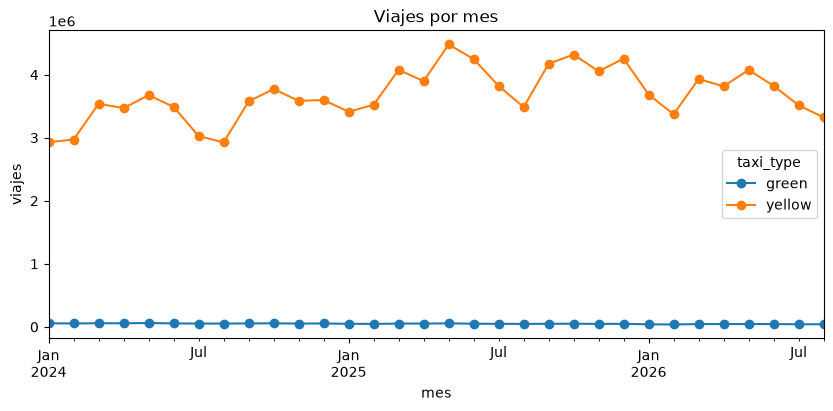

,taxi_type,mes,viajes,ingresos,total_prom
0,green,2024-01-01,56369,1267540.0,22.49
1,green,2024-02-01,53403,1214659.0,22.75
2,green,2024-03-01,57254,1318139.0,23.02
3,green,2024-04-01,56257,1322417.0,23.51
4,green,2024-05-01,60781,1501840.0,24.71


In [2]:
m = sql("02_eda/d10_tendencia_mensual.sql")
ax = m.pivot(index="mes", columns="taxi_type", values="viajes").plot(figsize=(10, 4), marker="o", ylabel="viajes", title="Viajes por mes")
plt.show()
m.head()

**Interpretacion / decision:** Yellow sube de 2024 a 2025 (+13 % a +27 % frente al mismo mes) y baja en 2026 (-3.5 % a -11.2 % de febrero a agosto; enero +7.2 %). Green baja todos los meses. 2026 llega solo hasta agosto, por eso no se compara un año completo.

## P2 - ¿Cuando se concentra la demanda?

Dia de la semana (0 = domingo) y hora.

Consulta: `sql/02_eda/d05_patron_hora_dia.sql`

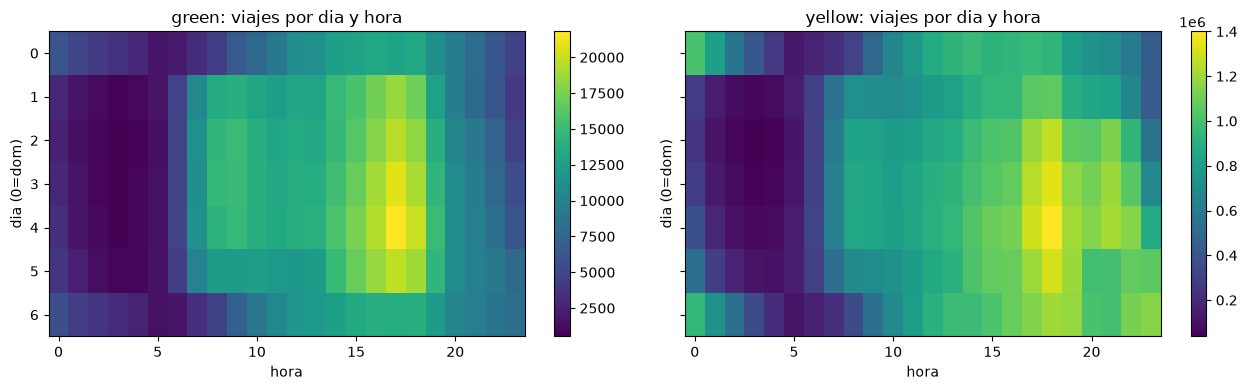

In [3]:
h = sql("02_eda/d05_patron_hora_dia.sql")
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (tipo, g) in zip(axes, h.groupby("taxi_type")):
    m = g.pivot(index="dia_semana", columns="hora", values="viajes")
    im = ax.imshow(m.values, aspect="auto", cmap="viridis")
    ax.set_title(f"{tipo}: viajes por dia y hora"); ax.set_xlabel("hora"); ax.set_ylabel("dia (0=dom)")
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

**Interpretacion / decision:** En yellow la hora pico es las 18 h (8.5 M de viajes) y el valle va de 4 a 5 h. Con `dia_semana` 0 = domingo, el lunes tiene menos viajes (14.6 M) y el jueves más (18.6 M).

## P3 - ¿Como es un viaje tipico?

Estadisticos, distribucion de la distancia, duracion y velocidad (caracteristicas de los viajes y distribucion de valores).

Consulta: `sql/02_eda/d01_estadisticos_numericos.sql`

In [4]:
sql("02_eda/d01_estadisticos_numericos.sql")

,taxi_type,n,dist_prom,dist_mediana,dist_p99,dist_max,tarifa_prom,tarifa_mediana,tarifa_p99,tarifa_max,total_prom,total_desv
0,green,1588707,16.99,1.95,17.25,262315.94,17.97,13.5,80.0,1676.70,24.88,19.95
1,yellow,119595677,5.88,1.81,19.72,398608.62,19.42,14.2,80.0,863372.12,28.01,103.03


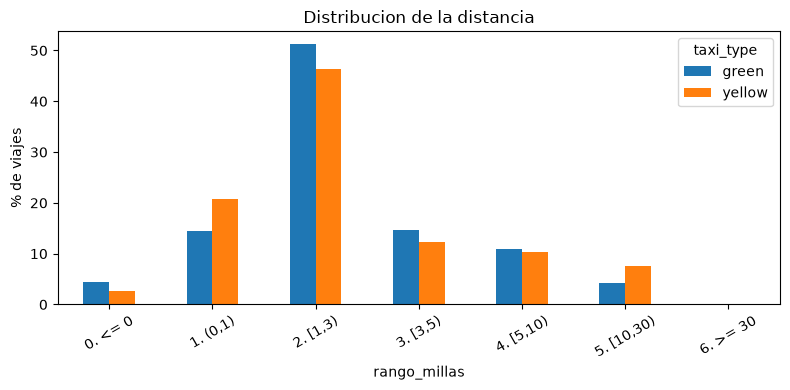

In [5]:
d = sql("02_eda/d03_distribucion_distancia.sql")
d.pivot(index="rango_millas", columns="taxi_type", values="porcentaje").plot.bar(figsize=(8, 4), ylabel="% de viajes", title="Distribucion de la distancia")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [6]:
sql("02_eda/d04_duracion_y_velocidad.sql")

,taxi_type,viajes,duracion_prom_min,duracion_mediana_min,duracion_p95_min,velocidad_prom_mph
0,green,1490116,15.8,12.6,38.2,67.7
1,yellow,115087147,17.3,13.6,44.0,21.1


**Interpretacion / decision:** La mediana describe mejor el viaje típico que el promedio: distancia mediana 1.81 millas en yellow y 1.95 en green (medias 5.88 y 16.99 por valores imposibles, máximo 398,608 millas); duración mediana 13.6 y 12.6 min. Cerca de la mitad de los viajes está entre 1 y 3 millas. La velocidad media de green (67.7 mph) es imposible: hay que usar la mediana o filtrar la distancia.

## P4 - ¿En que se diferencian yellow y green?

Comparacion directa en una tabla (volumen, distancia, duracion, tarifa, propina, tarjeta, aeropuertos).

Consulta: `sql/02_eda/d11_comparacion_yellow_green.sql`

In [7]:
sql("02_eda/d11_comparacion_yellow_green.sql")

,taxi_type,viajes,distancia_prom_millas,duracion_prom_min,tarifa_prom,propina_prom,total_prom,pasajeros_prom,pct_pago_tarjeta,pct_recogida_aeropuertos_jfk_lga
0,green,1477224,3.13,15.7,17.73,2.69,24.72,1.31,68.7,0.0
1,yellow,111160167,3.49,17.3,20.23,3.13,29.10,1.30,70.9,7.2


**Interpretacion / decision:** Yellow es más caro y largo (tarifa media 20.23 contra 17.73; 3.49 contra 3.13 millas; 17.3 contra 15.7 min) y concentra recogidas en las zonas 132 y 138, que la consulta trata como JFK y LGA (7.2 % contra 0.0 % en green). El pago con tarjeta es parecido (70.9 % y 68.7 %). Se pueden analizar juntos con `taxi_type`, sin promediarlos mezclados.

## P5 - ¿Como pagan y cuanto dejan de propina?

Variables relacionadas con el pago. Ojo: la propina en efectivo no se registra.

Consulta: `sql/02_eda/d06_pago_y_propinas.sql`

In [8]:
sql("02_eda/d06_pago_y_propinas.sql")

,taxi_type,payment_type,viajes,pct_viajes,propina_prom,propina_pct_tarifa
0,green,1,1081279,68.06,3.66,23.20
1,green,2,370766,23.34,0.00,0.00
2,green,3,10072,0.63,0.00,1.05
3,green,4,3555,0.22,0.01,0.05
4,green,5,52,0.00,0.00,0.00
5,green,<NA>,122983,7.74,1.63,6.99
6,yellow,0,23419814,19.58,0.43,2.09
7,yellow,1,80447167,67.27,4.33,26.14
8,yellow,2,12902464,10.79,0.00,0.00
9,yellow,3,698028,0.58,0.01,0.10


**Interpretacion / decision:** Con tarjeta la propina media es 4.33 en yellow (26 % de la tarifa); en efectivo es 0.00 porque no se registra. En yellow, `payment_type` 0 son 23,419,814 viajes (19.58 %) y coincide exactamente con los viajes con `passenger_count` nulo. Decisión: analizar propinas solo con tarjeta.

## P6 - ¿Que zonas concentran recogidas y destinos?

Zonas por ID de la TLC.

Consulta: `sql/02_eda/d07_zonas_recogida_destino.sql`

In [9]:
sql("02_eda/d07_zonas_recogida_destino.sql")

,zona,recogidas,bajadas,saldo_neto
0,237,5348392,4857696,490696
1,132,5234798,1199177,4035621
2,161,5227622,4285768,941854
3,236,4783937,5013328,-229391
4,162,3829302,3255901,573401
5,186,3809837,2577041,1232796
6,230,3760742,3583571,177171
7,142,3550484,3148211,402273
8,138,3328127,1278561,2049566
9,170,3247812,3384195,-136383


**Interpretacion / decision:** Las zonas 237, 132 y 161 concentran más recogidas (5.3 M, 5.2 M y 5.2 M). La zona 132 tiene 5.2 M de recogidas y 1.2 M de bajadas (saldo neto +4.0 M). Son ids de zona: no hay tabla de nombres en el repositorio.

## P7 - ¿Que variables se relacionan?

Correlaciones entre distancia, tarifa, total, propina y pasajeros.

Consulta: `sql/02_eda/d08_correlaciones.sql`

In [10]:
sql("02_eda/d08_correlaciones.sql")

,taxi_type,corr_distancia_tarifa,corr_distancia_total,corr_tarifa_propina,corr_pasajeros_total
0,green,0.745,0.836,0.417,0.028
1,yellow,0.914,0.903,0.527,0.056


**Interpretacion / decision:** Distancia y tarifa están muy correlacionadas en yellow (0.91) y algo menos en green (0.74); los pasajeros casi no se relacionan con el total (0.06 y 0.03). La distancia es el mejor predictor de la tarifa.

## P8 - ¿Cuantos registros son inconsistentes o atipicos?

Conteo de registros sospechosos y atipicos de tarifa por IQR.

Consulta: `sql/02_eda/d02_calidad_datos.sql`

In [11]:
sql("02_eda/d02_calidad_datos.sql")

,taxi_type,viajes,bajada_antes_de_recogida,duracion_mayor_24h,distancia_cero_o_negativa,tarifa_cero_o_negativa,total_negativo,pasajeros_nulo_o_cero,zona_recogida_invalida,fecha_fuera_de_2024_2026
0,green,1588707,1351.0,6.0,71224.0,13015.0,4971.0,142558.0,0.0,20.0
1,yellow,119595677,3820.0,845.0,3131494.0,3798269.0,1744900.0,24172589.0,0.0,68.0


In [12]:
sql("02_eda/d09_atipicos_iqr.sql")

,taxi_type,q1,q3,limite_superior,atipicos_altos,pct_atipicos
0,green,9.30,20.5,37.30,123447,7.83
1,yellow,9.58,24.0,45.63,9450800,8.16


**Interpretacion / decision:** Se filtra distancia 0.1-100 millas, tarifa 1-500 y duración 1-180 min en cada consulta. El criterio IQR marcaría ~8 % de las tarifas como atípicas altas (9.45 M de viajes en yellow, límite 45.63): son viajes largos legítimos, así que no se eliminan por IQR; se usa el filtro fijo de negocio.

## Hallazgos relevantes (4.5)

1. **Los promedios engañan por valores imposibles** (`d01`, `d04`): distancia media de yellow 5.88 millas contra una mediana de 1.81 (máximo 398,608); velocidad media de green 67.7 mph. Se usa mediana y se filtran viajes plausibles.
2. **La propina solo existe con tarjeta** (`d06`): tarjeta es el 67.3 % de los viajes yellow con propina media de 4.33; efectivo es el 10.8 % con 0.00. Cualquier indicador de propina debe limitarse a `payment_type = 1`.
3. **El 19.58 % de yellow tiene `payment_type` 0 y `passenger_count` nulo a la vez** (23,419,814 viajes, `d06` y `p09`): no usar `passenger_count` como filtro y tratar `payment_type` 0 como "sin dato".
4. **El IQR no sirve para limpiar tarifas** (`d09`): marcaría 8.16 % de yellow como atípico alto; son viajes largos legítimos.
5. **La demanda cambia de signo entre años y tipos** (`d10`): yellow sube en 2025 y baja en 2026; green baja todos los meses. Comparar siempre el mismo mes.
6. **La zona 132 concentra salidas con poco retorno** (`d07`): 5.2 M de recogidas contra 1.2 M de bajadas.